<a href="https://colab.research.google.com/github/felondrum/llm_driven_development_otus/blob/develop/llm_otus_filippov_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Шаг 1: Установка необходимых библиотек

    ┌───────────────────────┬───────────────────────────────────────────────────────┐
    │ Библиотека            │ Зачем                                                 │
    ├───────────────────────┼───────────────────────────────────────────────────────┤
    │ datasets              │ Загрузка датасета Sberquad из HuggingFace             │
    │ transformers + torch  │ Запуск локальных языковых моделей                     │
    │ evaluate, nltk        │ Расчёт BLEU-метрики                                   │
    │ sentence-transformers │ Semantic Similarity — косинусная близость эмбеддингов │
    │ pandas                │ Хранение и агрегация результатов                      │
    │ matplotlib, seaborn   │ Визуализация и сравнение моделей                      │

In [149]:
!pip install datasets transformers torch evaluate nltk sacrebleu sentence-transformers tqdm pandas matplotlib seaborn

Импорт зависимостей

    Импортируем всё необходимое для дальнейшей работы.
    
    ------
  
    Настраиваем seaborn для красивых график и скачиваем punkt для токенизации NLTK.

In [96]:
import os
import time
import re
import string
from collections import Counter

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from datasets import load_dataset

from transformers import (
  AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
  AutoModelForQuestionAnswering
)

import evaluate
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sentence_transformers import SentenceTransformer, util

import nltk
nltk.download('punkt', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Загружаем датасет kuznetsoffandrey/sberquad — это русскоязычный QA-датасет, аналог SQuAD. Каждый пример содержит:

     - context — текст-контекст
     - question — вопрос по контексту
     - answers — эталонные ответы (список с позициями)

In [3]:
dataset = load_dataset("kuznetsoffandrey/sberquad")
print("Доступные сплиты:", dataset.keys())
print("\nСтруктура:")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

sberquad/train-00000-of-00001.parquet:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

sberquad/validation-00000-of-00001.parqu(…):   0%|          | 0.00/3.43M [00:00<?, ?B/s]

sberquad/test-00000-of-00001.parquet:   0%|          | 0.00/4.93M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Доступные сплиты: dict_keys(['train', 'validation', 'test'])

Структура:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 45328
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 5036
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 23936
    })
})


Sberquad имеет вложенную структуру — answers это словарь с ключами text (список ответов) и answer_start (позиции). Убедимся, что правильно понимаем формат.

In [4]:
sample = dataset['validation'][0]
print("Контекст:", sample['context'][:200], "...")
print("\nВопрос:", sample['question'])
print("\nОтветы:", sample['answers'])

Контекст: Первые упоминания о строении человеческого тела встречаются в Древнем Египте. В XXVII веке до н. э. египетский врач Имхотеп описал некоторые органы и их функции, в частности головной мозг, деятельност ...

Вопрос: Где встречаются первые упоминания о строении человеческого тела?

Ответы: {'text': ['в Древнем Египте'], 'answer_start': [60]}


Подготовка выборки из 50 примеров

    Формируем DataFrame для оценки. Берём сплит validation — он меньше и репрезентативнее для тестирования. В качестве эталонного ответа используем первый вариант из списка ответов.

In [154]:
NUM_SAMPLES = 50

data = dataset['validation']
data_subset = data.select(range(min(NUM_SAMPLES, len(data))))

samples = []
for item in data_subset:
  gt_answers = item['answers']['text']
  if gt_answers and len(gt_answers) > 0:
     samples.append({
     'context': item['context'],
     'question': item['question'],
     'ground_truth': gt_answers[0]
     })

df = pd.DataFrame(samples)
print(f"Всего примеров для оценки: {len(df)}")
df.head()


Всего примеров для оценки: 50


,context,question,ground_truth
0,Первые упоминания о строении человеческого тел...,Где встречаются первые упоминания о строении ч...,в Древнем Египте
1,Первые упоминания о строении человеческого тел...,Когда египетский врач Имхотеп впервые описал н...,В XXVII веке до н. э.
2,Телескоп имеет модульную структуру и содержит ...,Как называется корректирующая оптическая систе...,COSTAR
3,Критики теории Вегенера поставили во главу угл...,Какая теория была отвергнута после смерти Веге...,теория дрейфа материков
4,При нагревании кусочки янтаря становятся очень...,Чему не уступают по красоте изделия из прессов...,изделиям из монолитных камней


Шаг 3: Определение устройства вычислений

    Проверяем, доступен ли GPU. Все модели будут загружены на доступное устройство. Если только CPU — генерация 200 примеров тремя моделями будет очень медленной

In [155]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

if device.type == 'cpu':
   print("⚠️ GPU не обнаружен. Генерация на CPU может быть очень медленной.")
   print("   Рекомендуется Google Colab с GPU или уменьшение NUM_SAMPLES до 20-50")

Используемое устройство: cpu
⚠️ GPU не обнаружен. Генерация на CPU может быть очень медленной.
   Рекомендуется Google Colab с GPU или уменьшение NUM_SAMPLES до 20-50


Авторизуемся на hugging face

In [156]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)


Модель 1: ruGPT-3 Medium

Русскоязычная GPT среднего размера (~400M). Легче и быстрее, чем Large версия. Causal LM — генерирует продолжение текста.

Модель 2: ruGPT-3 Large

Большая русскоязычная GPT (~760M). Более качественная генерация, но медленнее. Тоже causal LM.

In [9]:
print("Загрузка ruGPT3-Large...")

rugpt2_tokenizer = AutoTokenizer.from_pretrained('ai-forever/rugpt3large_based_on_gpt2')
rugpt2_model = AutoModelForCausalLM.from_pretrained(
     'ai-forever/rugpt3large_based_on_gpt2',
      torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
      device_map='auto' if device.type == 'cuda' else None
      )

if device.type == 'cpu':
  rugpt2_model = rugpt2_model.to(device)

rugpt2_model.eval()
print("✅ ruGPT3-Large загружена")

Загрузка ruGPT3-Large...


config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3large_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ ruGPT3-Large загружена


Модель: MilyaShams/rubert-russian-qa-sberquad

Тип: question-answering
Базовая архитектура: DeepPavlov/rubert-base-cased
Особенности: Эта модель дообучена на датасете SberQUAD и хорошо подходит для извлечения ответов из предоставленного контекста.

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME_QA = "MilyaShams/rubert-russian-qa-sberquad"

print(f"Загрузка модели {MODEL_NAME_QA}...")
tokenizer_qa = AutoTokenizer.from_pretrained(MODEL_NAME_QA)
model_qa = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME_QA).to(device)

print("Модель успешно загружена!")

Загрузка модели MilyaShams/rubert-russian-qa-sberquad...


model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель успешно загружена!


Функция генерации для ruGPT-3 (causal LM)

  Обе GPT-модели работают одинаково: получают промпт (контекст + вопрос) и продолжают текст. Обрезаем ответ по первой строке/точке, чтобы получить краткий ответ, а не продолжение рассуждений.

In [98]:
def generate_gpt(context, question, model, tokenizer):
    # Максимально простой промпт. Модель лучше следует формату, чем длинным инструкциям.
    # Формат: Контекст -> Вопрос -> Ответ (без лишних слов)
    prompt_text = f"Контекст: {context}\n\nВопрос: {question}\n\nОтвет:"

    inputs = tokenizer(prompt_text, return_tensors='pt', truncation=True, max_length=1024).to(device)
    input_len = inputs['input_ids'].shape[1]

    # Определяем токены для остановки: новая строка (\n) и точка (.)
    # Это заставит модель остановиться сразу после первого предложения/фразы
    eos_tokens = ["\n", "."]
    eos_token_ids = [tokenizer.encode(t, add_special_tokens=False)[0] for t in eos_tokens if len(tokenizer.encode(t, add_special_tokens=False)) == 1]

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,       # Достаточно для короткого ответа
            min_new_tokens=2,        # Минимум 2 токена
            temperature=0.3,         # Чуть выше нуля, чтобы не зацикливалась на одном слове
            do_sample=True,
            repetition_penalty=1.2,  # Мягкий штраф за повторы
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=eos_token_ids # ГЛАВНОЕ: стоп по newline или точке
        )
    elapsed = time.time() - start_time

    # Декодируем только сгенерированную часть
    generated_ids = outputs[0][input_len:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Удаляем возможные остатки стоп-символов, если они попали в текст
    answer = answer.strip().rstrip('.').strip()

    return answer, elapsed

 Функция генерации для QA

In [157]:
def generate_qa_model(context, question, model, tokenizer):
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        return_offsets_mapping=True
    ).to(device)

    offset_mapping = inputs.pop("offset_mapping")

    start_time = time.time()
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits
    end_logits = outputs.end_logits

    start_index = torch.argmax(start_logits)
    end_index = torch.argmax(end_logits) + 1

    if end_index < start_index:
        end_index = start_index + 1

    answer_token_ids = inputs['input_ids'][0][start_index:end_index]

    answer = tokenizer.decode(answer_token_ids, skip_special_tokens=True).strip()

    elapsed = time.time() - start_time

    if not answer:
        answer = "Ответ не найден"

    return answer, elapsed

Подключение API Yandex

In [171]:
from google.colab import userdata
from typing import Dict, List, Any
import re

# Интеграция с YandexGPT через API
def generate_yandexgpt(context, question, api_key=None, host=None):
    """
    Генерация ответа с использованием YandexGPT API.
    Требуется api_key и host (endpoint)
    """
    import time
    import requests

    if not api_key or not host:
        return "Ошибка: не указан API ключ или хост", 0

    prompt_text = f"Контекст: {context}\n\nВопрос: {question}\n\nОтвет:"

    messages = [
        {
            "role": "user",
            "text": prompt_text
        }
        ]

    start_time = time.time()

    url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
    headers = {
        'Content-Type': 'application/json',
        'Authorization': f'Api-Key {api_key}'
    }



    body = {
        "modelUri": f"gpt://{host}/yandexgpt-lite",
        "completionOptions": {
            "stream": False,
            "temperature": 0.3,
            "maxTokens": "50"
        },
        "messages": messages
    }


    try:
        response = requests.post(url, headers=headers, json=body, timeout=30)
        response.raise_for_status()
        result = response.json()

        answer = result['result']['alternatives'][0]['message']['text'].strip()
        elapsed = time.time() - start_time

        return answer, elapsed
    except Exception as e:
        elapsed = time.time() - start_time
        return f"Ошибка API: {str(e)}", elapsed

print("✅ Функция generate_yandexgpt определена")

✅ Функция generate_yandexgpt определена


 Словарь моделей для итерации

  Собираем все модели в словарь. Ключ — название модели для результатов, значение — кортеж (объект модели, токенизатор, функция генерации).

In [174]:

# Получение ключей из userdata
key = userdata.get('YA_LLM_KEY')
host = userdata.get('YA_HOST_KEY')

# Конфигурация моделей (без ruGPT3-Medium)
models_config = {
    'YandexGPT-Lite': (None, None, generate_yandexgpt, key, host),
    'ruGPT3-Large':  (rugpt2_model, rugpt2_tokenizer, generate_gpt),
    'Rubert-QA-Sberquad': (model_qa, tokenizer_qa, generate_qa_model),
}

print("✅ Конфигурация моделей обновлена")


✅ Конфигурация моделей обновлена


Тест на одном примере

Проверяем, что все модели генерируют ответы. Запускаем на первом примере из датасета.

In [175]:
# Тест на одном примере
test_idx = 0
test_ctx = df.iloc[test_idx]['context']
test_q = df.iloc[test_idx]['question']
test_gt = df.iloc[test_idx]['ground_truth']

print(f"Вопрос: {test_q}")
print(f"Эталонный ответ: {test_gt}")
print("-" * 60)

for name, config in models_config.items():
    # unpacking конфигурации в зависимости от количества элементов
    if len(config) == 5:
        model, tokenizer, gen_fn, api_key, host_url = config
    else:
        model, tokenizer, gen_fn = config
        api_key, host_url = None, None

    try:
        # Для YandexGPT передаем api_key и host, для остальных - model и tokenizer
        if name == 'YandexGPT-Lite':
            answer, t = gen_fn(test_ctx, test_q, api_key, host_url)
        else:
            answer, t = gen_fn(test_ctx, test_q, model, tokenizer)
        print(f"{name}: {answer} (время: {t:.2f}с)")
    except Exception as e:
        print(f"{name}: ОШИБКА — {e}")

Вопрос: Где встречаются первые упоминания о строении человеческого тела?
Эталонный ответ: в Древнем Египте
------------------------------------------------------------
YandexGPT-Lite: Первые упоминания о строении человеческого тела встречаются в Древнем Египте, Древнем Китае и в Индии. (время: 1.27с)
ruGPT3-Large: Первое упоминание об устройстве человеческого организма встречается у древних египтян – это папирусная табличка «Устройство человеческого тела» из музея Карнаке ( (время: 14.65с)
Rubert-QA-Sberquad: в Древнем Египте (время: 0.55с)


Генерация ответов на всех 200 примерах

In [177]:
results = []

for model_name, config in models_config.items():
    print(f"\n{'='*60}")
    print(f"Генерация моделью: {model_name}")
    print(f"{'='*60}")

    # Распаковка конфигурации в зависимости от количества элементов
    if len(config) == 5:
        # Для API моделей (YandexGPT): model, tokenizer, gen_fn, api_key, host
        _, _, gen_fn, api_key, host_url = config
    else:
        # Для локальных моделей: model, tokenizer, gen_fn
        model, tokenizer, gen_fn = config
        api_key, host_url = None, None

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=model_name):
        try:
            # Вызов функции генерации с правильными аргументами
            if model_name == 'YandexGPT-Lite':
                prediction, elapsed = gen_fn(row['context'], row['question'], api_key, host_url)
            else:
                prediction, elapsed = gen_fn(row['context'], row['question'], model, tokenizer)

            results.append({
                'model': model_name,
                'question': row['question'],
                'context': row['context'],
                'ground_truth': row['ground_truth'],
                'prediction': prediction,
                'time_seconds': elapsed,
                'prediction_length': len(prediction)
            })
        except Exception as e:
            print(f"\nОшибка на примере {idx}: {e}")
            results.append({
                'model': model_name,
                'question': row['question'],
                'context': row['context'],
                'ground_truth': row['ground_truth'],
                'prediction': '',
                'time_seconds': 0,
                'prediction_length': 0
            })

results_df = pd.DataFrame(results)
results_df['prediction_clean'] = results_df['prediction'].apply(postprocess_answer)
print(f"\n✅ Всего сгенерировано ответов: {len(results_df)}")
results_df.head()


Генерация моделью: YandexGPT-Lite


YandexGPT-Lite:   0%|          | 0/50 [00:00<?, ?it/s]


Генерация моделью: ruGPT3-Large


ruGPT3-Large:   0%|          | 0/50 [00:00<?, ?it/s]


Генерация моделью: Rubert-QA-Sberquad


Rubert-QA-Sberquad:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Всего сгенерировано ответов: 150


,model,question,context,ground_truth,prediction,time_seconds,prediction_length,prediction_clean
0,YandexGPT-Lite,Где встречаются первые упоминания о строении ч...,Первые упоминания о строении человеческого тел...,в Древнем Египте,Первые упоминания о строении человеческого тел...,1.522776,102,Первые упоминания о строении человеческого тел...
1,YandexGPT-Lite,Когда египетский врач Имхотеп впервые описал н...,Первые упоминания о строении человеческого тел...,В XXVII веке до н. э.,В XXVII веке до н. э.,0.862590,21,В XXVII веке до н. э.
2,YandexGPT-Lite,Как называется корректирующая оптическая систе...,Телескоп имеет модульную структуру и содержит ...,COSTAR,COSTAR,0.959349,6,COSTAR
3,YandexGPT-Lite,Какая теория была отвергнута после смерти Веге...,Критики теории Вегенера поставили во главу угл...,теория дрейфа материков,Теория дрейфа материков.,0.797295,24,Теория дрейфа материков.
4,YandexGPT-Lite,Чему не уступают по красоте изделия из прессов...,При нагревании кусочки янтаря становятся очень...,изделиям из монолитных камней,Изделия из прессованного янтаря не уступают по...,1.137288,85,Изделия из прессованного янтаря не уступают по...


Функции для вычисления QA-метрик

Стандартные метрики для QA-задач (как в SQuAD):
  - Exact Match — точное совпадение нормализованного предсказания с эталоном
  - F1-score — пересечение токенов (precision × recall / 2)
  - BLEU — совпадение n-gram с smoothing для коротких ответов

In [178]:
def normalize_answer(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join(text.split())
    return text


def exact_match(prediction, ground_truth):
    return int(normalize_answer(prediction) == normalize_answer(ground_truth))


def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()

    if not gt_tokens:
        return 0.0

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens) if pred_tokens else 0
    recall = num_same / len(gt_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall)


def bleu_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = [normalize_answer(ground_truth).split()]

    if not pred_tokens or not gt_tokens[0]:
        return 0.0

    smoothing = SmoothingFunction().method1
    return sentence_bleu(gt_tokens, pred_tokens, smoothing_function=smoothing)

Вычисление метрик для каждого ответа

Применяем все три метрики к каждой строке results_df.

In [179]:
results_df['em'] = results_df.apply(
    lambda row: exact_match(row['prediction'], row['ground_truth']), axis=1
)
results_df['f1'] = results_df.apply(
    lambda row: f1_score(row['prediction'], row['ground_truth']), axis=1
)
results_df['bleu'] = results_df.apply(
    lambda row: bleu_score(row['prediction'], row['ground_truth']), axis=1
)

print("✅ Метрики F1, EM, BLEU рассчитаны")
results_df[['model', 'ground_truth', 'prediction', 'em', 'f1', 'bleu']].head(10)

✅ Метрики F1, EM, BLEU рассчитаны


,model,ground_truth,prediction,em,f1,bleu
0,YandexGPT-Lite,в Древнем Египте,Первые упоминания о строении человеческого тел...,0,0.333333,0.065419
1,YandexGPT-Lite,В XXVII веке до н. э.,В XXVII веке до н. э.,1,1.000000,1.000000
2,YandexGPT-Lite,COSTAR,COSTAR,1,1.000000,0.177828
3,YandexGPT-Lite,теория дрейфа материков,Теория дрейфа материков.,1,1.000000,0.562341
4,YandexGPT-Lite,изделиям из монолитных камней,Изделия из прессованного янтаря не уступают по...,0,0.500000,0.212006
5,YandexGPT-Lite,оральные и назальные,Дифтонги делятся на две группы: оральные и наз...,0,0.545455,0.137471
6,YandexGPT-Lite,как хиатусы,Восходящие дифтонги со слабым гласным /i/ и /u...,0,0.266667,0.032857
7,YandexGPT-Lite,на предсказуемость швейцарского правового порядка,Зарубежные клиенты смогут и далее рассчитывать...,0,0.625000,0.350844
8,YandexGPT-Lite,деталями соглашения,Детлями соглашения.,0,0.500000,0.149535
9,YandexGPT-Lite,суд первой инстанции,Каждый судебный округ имеет суд первой инстанц...,0,0.200000,0.034547


Сводная таблица метрик по моделям

Агрегируем средние значения метрик по каждой модели. Стандартное отклонение для времени и длины ответа показывает стабильность модели.

In [180]:
agg_metrics = results_df.groupby('model').agg({
    'em': 'mean',
    'f1': 'mean',
    'bleu': 'mean',
    'time_seconds': ['mean', 'std'],
    'prediction_length': ['mean', 'std']
}).round(4)

agg_metrics.columns = ['EM (mean)', 'F1 (mean)', 'BLEU (mean)',
                       'Time (mean)', 'Time (std)',
                       'Length (mean)', 'Length (std)']

print("\n📊 Сводная таблица метрик по моделям:")
agg_metrics


📊 Сводная таблица метрик по моделям:


,EM (mean),F1 (mean),BLEU (mean),Time (mean),Time (std),Length (mean),Length (std)
model,,,,,,,
Rubert-QA-Sberquad,0.68,0.8461,0.4207,0.7230,0.4157,26.78,35.1279
YandexGPT-Lite,0.36,0.6992,0.3114,0.9188,0.1868,53.08,55.8609
ruGPT3-Large,0.00,0.0503,0.0094,12.5248,3.7863,95.92,44.7007


Загрузка модели для семантической близости

Используем paraphrase-multilingual-MiniLM — легковесная мультиязычная модель sentence embeddings. Она создаёт векторные представления текстов: семантически близкие тексты будут иметь высокий
cosine similarity.

In [181]:
print("Загрузка модели семантической близости...")
semantic_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print("✅ Модель загружена")

Загрузка модели семантической близости...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Модель загружена


Вычисление Semantic Similarity

Для каждой пары (ground_truth, prediction) вычисляем косинусную близость эмбеддингов. Обрабатываем батчами по 32 для экономии памяти.

In [182]:

def compute_semantic_similarity(texts1, texts2, batch_size=32):
    similarities = []

    for i in tqdm(range(0, len(texts1), batch_size), desc='Semantic Similarity'):
        batch1 = texts1[i:i+batch_size]
        batch2 = texts2[i:i+batch_size]

        emb1 = semantic_model.encode(batch1, convert_to_tensor=True)
        emb2 = semantic_model.encode(batch2, convert_to_tensor=True)

        cos_sim = util.cos_sim(emb1, emb2)
        # Диагональ — пары (gt_i, pred_i)
        similarities.extend(torch.diag(cos_sim).cpu().numpy().tolist())

    return similarities

print("Вычисление Semantic Similarity...")
results_df['semantic_similarity'] = compute_semantic_similarity(
      results_df['ground_truth'].tolist(),
      results_df['prediction'].tolist()
)

print("✅ Semantic Similarity рассчитана")

Вычисление Semantic Similarity...


Semantic Similarity:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Semantic Similarity рассчитана


Добавляем Semantic Similarity в сводную таблицу

Вычисляем среднюю семантическую близость по каждой модели и обновляем итоговую таблицу.

In [183]:
semantic_by_model = results_df.groupby('model')['semantic_similarity'].mean()
agg_metrics['Semantic Sim (mean)'] = semantic_by_model.round(4)

print("\n📊 Обновлённая сводная таблица:")
agg_metrics


📊 Обновлённая сводная таблица:


,EM (mean),F1 (mean),BLEU (mean),Time (mean),Time (std),Length (mean),Length (std),Semantic Sim (mean)
model,,,,,,,,
Rubert-QA-Sberquad,0.68,0.8461,0.4207,0.7230,0.4157,26.78,35.1279,0.9242
YandexGPT-Lite,0.36,0.6992,0.3114,0.9188,0.1868,53.08,55.8609,0.7876
ruGPT3-Large,0.00,0.0503,0.0094,12.5248,3.7863,95.92,44.7007,0.3185


Сравнение моделей по основным метрикам

Столбчатая диаграмма показывает EM, F1 и BLEU для каждой модели. Чем выше столбец — тем лучше.

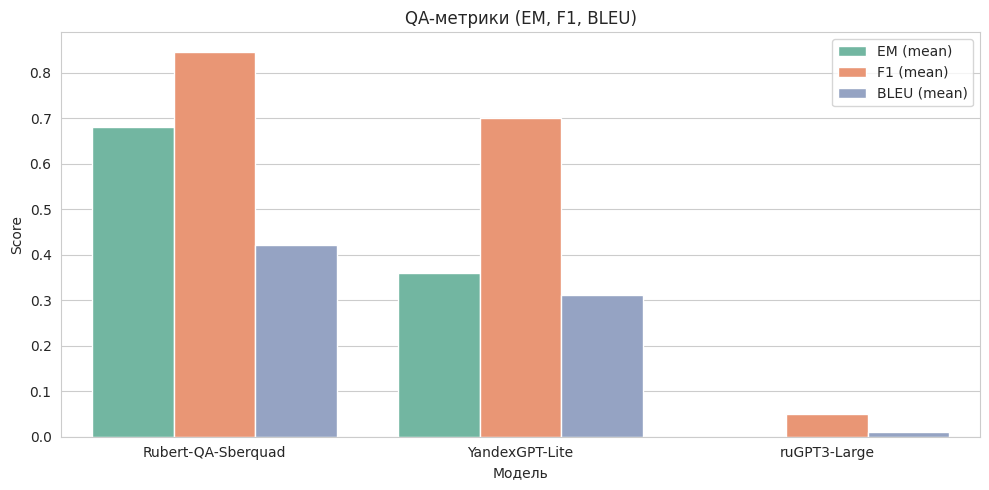

In [184]:
metrics_data = agg_metrics[['EM (mean)', 'F1 (mean)', 'BLEU (mean)']].reset_index()
metrics_melted = metrics_data.melt(id_vars='model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x='model', y='Score', hue='Metric', palette='Set2')
plt.title('QA-метрики (EM, F1, BLEU)')
plt.ylabel('Score')
plt.xlabel('Модель')
plt.legend()
plt.tight_layout()
plt.show()

Semantic Similarity и время генерации

Отдельные графики показывают семантическую близость ответов и скорость работы моделей.

/tmp/ipykernel_3171/2952131882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y='semantic_similarity', ax=axes[0], palette='Set3')
/tmp/ipykernel_3171/2952131882.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y='time_seconds', ax=axes[1], palette='Set1')


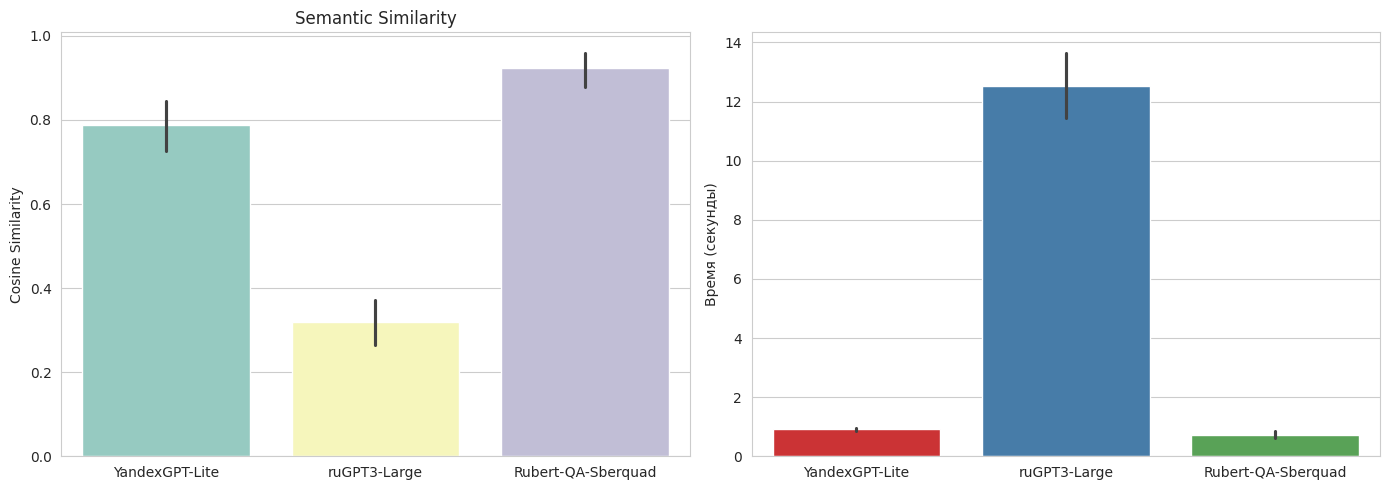

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='model', y='semantic_similarity', ax=axes[0], palette='Set3')
axes[0].set_title('Semantic Similarity')
axes[0].set_ylabel('Cosine Similarity')
axes[0].set_xlabel('')

sns.barplot(data=results_df, x='model', y='time_seconds', ax=axes[1], palette='Set1')
axes[1].set_ylabel('Время (секунды)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

Распределение метрик (boxplot)

Boxplot показывает разброс значений F1 и Semantic Similarity — насколько стабильна модель. Медиана, квартили и выбросы.

/tmp/ipykernel_3171/154949612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='model', y='f1', ax=axes[0], palette='Set2')
/tmp/ipykernel_3171/154949612.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='model', y='semantic_similarity', ax=axes[1], palette='Set2')


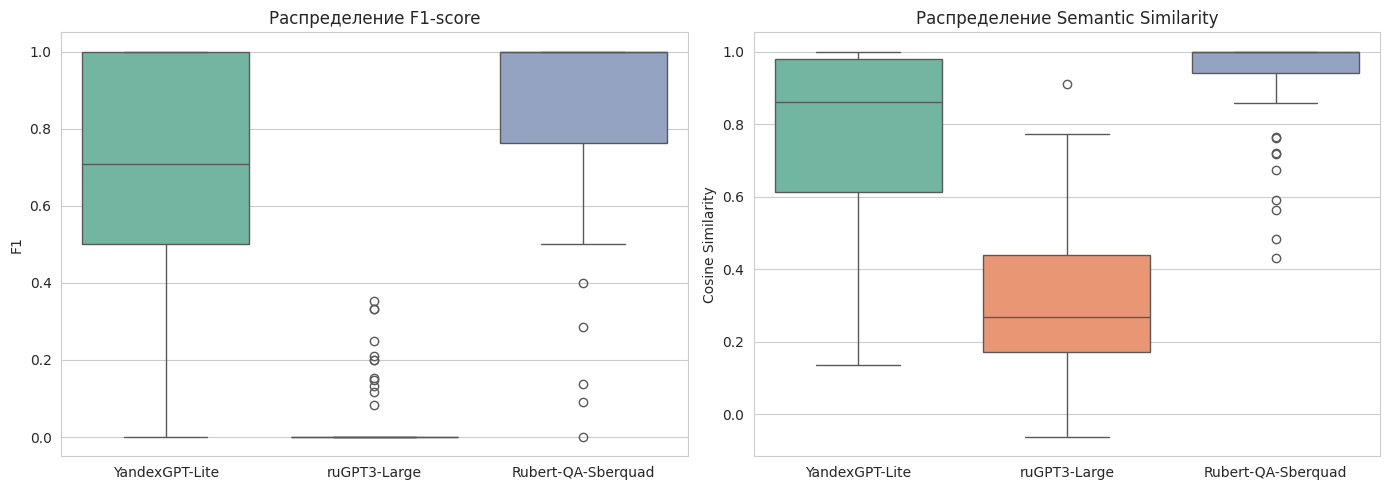

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=results_df, x='model', y='f1', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение F1-score')
axes[0].set_ylabel('F1')
axes[0].set_xlabel('')

sns.boxplot(data=results_df, x='model', y='semantic_similarity', ax=axes[1], palette='Set2')
axes[1].set_title('Распределение Semantic Similarity')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

Heatmap нормализованных метрик

Нормализуем все метрики к [0,1] для наглядного сравнения. Для времени: чем меньше — тем лучше (инвертируем). Ярче = лучше.

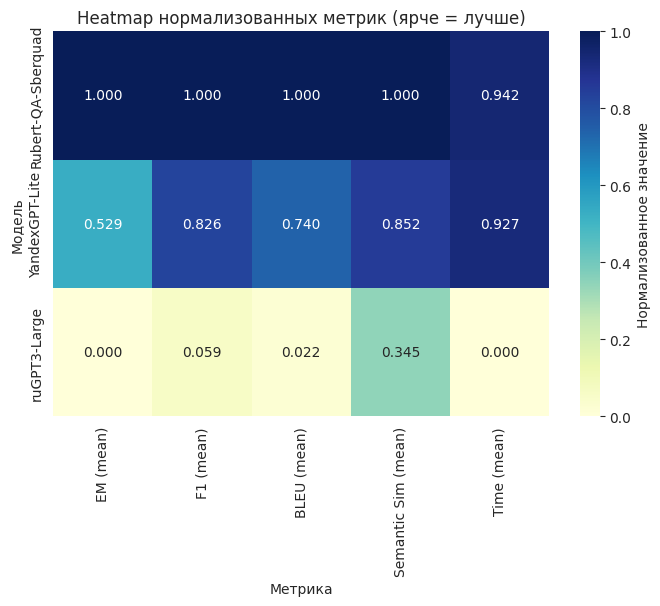

In [187]:
heatmap_data = agg_metrics[['EM (mean)', 'F1 (mean)', 'BLEU (mean)', 'Semantic Sim (mean)']].copy()
heatmap_normalized = (heatmap_data / heatmap_data.max()).round(3)

# Время: чем меньше, тем лучше — инвертируем
heatmap_normalized['Time (mean)'] = 1 - (agg_metrics['Time (mean)'] / agg_metrics['Time (mean)'].max())

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_normalized, annot=True, cmap='YlGnBu', fmt='.3f',
       cbar_kws={'label': 'Нормализованное значение'})
plt.title('Heatmap нормализованных метрик (ярче = лучше)')
plt.ylabel('Модель')
plt.xlabel('Метрика')
plt.show()

Итоговый рейтинг и ранжирование

Для каждой метрики присваиваем ранг (1 = лучшая). Средний ранг определяет общего победителя. Показываем примеры ответов лучшей модели.

In [188]:
final_report = agg_metrics.copy()

final_report['EM rank'] = final_report['EM (mean)'].rank(ascending=False).astype(int)
final_report['F1 rank'] = final_report['F1 (mean)'].rank(ascending=False).astype(int)
final_report['BLEU rank'] = final_report['BLEU (mean)'].rank(ascending=False).astype(int)
final_report['Semantic Sim rank'] = final_report['Semantic Sim (mean)'].rank(ascending=False).astype(int)
final_report['Time rank'] = final_report['Time (mean)'].rank(ascending=True).astype(int)

final_report['Avg rank'] = final_report[['EM rank', 'F1 rank', 'BLEU rank', 'Semantic Sim rank', 'Time rank']].mean(axis=1).round(2)

print("=" * 70)
print("🏆 ИТОГОВЫЙ РЕЙТИНГ МОДЕЛЕЙ")
print("=" * 70)
print(final_report.to_string())
print()

best_model = final_report['Avg rank'].idxmin()
print(f"🥇 Лучшая модель по среднему рангу: {best_model}")

🏆 ИТОГОВЫЙ РЕЙТИНГ МОДЕЛЕЙ
                    EM (mean)  F1 (mean)  BLEU (mean)  Time (mean)  Time (std)  Length (mean)  Length (std)  Semantic Sim (mean)  EM rank  F1 rank  BLEU rank  Semantic Sim rank  Time rank  Avg rank
model                                                                                                                                                                                                
Rubert-QA-Sberquad       0.68     0.8461       0.4207       0.7230      0.4157          26.78       35.1279               0.9242        1        1          1                  1          1       1.0
YandexGPT-Lite           0.36     0.6992       0.3114       0.9188      0.1868          53.08       55.8609               0.7876        2        2          2                  2          2       2.0
ruGPT3-Large             0.00     0.0503       0.0094      12.5248      3.7863          95.92       44.7007               0.3185        3        3          3                  3     

Примеры ответов лучшей модели

Качественный анализ: смотрим на конкретные ответы лучшей модели и сравниваем с эталоном. Это помогает понять, где метрики «недооценивают» модель.

In [189]:
best_model_name = final_report['Avg rank'].idxmin()
best_model_results = results_df[results_df['model'] == best_model_name].head(10)

print(f"📝 Примеры ответов модели {best_model_name}:\n")
for _, row in best_model_results.iterrows():
    print(f"В: {row['question']}")
    print(f"Эталон: {row['ground_truth']}")
    print(f"Ответ:  {row['prediction']}")
    print(f"F1={row['f1']:.2f}, EM={row['em']}, BLEU={row['bleu']:.2f}, Sim={row['semantic_similarity']:.2f}")
    print("-" * 80)

📝 Примеры ответов модели Rubert-QA-Sberquad:

В: Где встречаются первые упоминания о строении человеческого тела?
Эталон: в Древнем Египте
Ответ:  в Древнем Египте
F1=1.00, EM=1, BLEU=0.56, Sim=1.00
--------------------------------------------------------------------------------
В: Когда египетский врач Имхотеп впервые описал некоторые органы и их функции?
Эталон: В XXVII веке до н. э.
Ответ:  В XXVII веке до н. э.
F1=1.00, EM=1, BLEU=1.00, Sim=1.00
--------------------------------------------------------------------------------
В: Как называется корректирующая оптическая система, установленная на телескоп во время первой экспедиции обслуживания в 1993 году для компенсации неточности изготовления главного зеркала?
Эталон: COSTAR
Ответ:  COSTAR
F1=1.00, EM=1, BLEU=0.18, Sim=1.00
--------------------------------------------------------------------------------
В: Какая теория была отвергнута после смерти Вегенера?
Эталон: теория дрейфа материков
Ответ:  теория дрейфа материков
F1=1.00, EM

In [190]:

def calculate_exact_match(pred, true):
    """Вычисляет Exact Match (полное совпадение)."""
    if not isinstance(pred, str): pred = str(pred)
    if not isinstance(true, str): true = str(true)

    pred = pred.strip().lower()
    true = true.strip().lower()

    # Убираем лишние знаки препинания для мягкого сравнения
    pred = re.sub(r'[^\w\sа-яё0-9]', '', pred)
    true = re.sub(r'[^\w\sа-яё0-9]', '', true)

    return 1.0 if pred == true else 0.0

def calculate_f1(pred, true):
    """Вычисляет F1-score на основе токенов."""
    if not isinstance(pred, str): pred = str(pred)
    if not isinstance(true, str): true = str(true)

    pred = pred.strip().lower()
    true = true.strip().lower()

    pred = re.sub(r'[^\w\sа-яё0-9]', '', pred)
    true = re.sub(r'[^\w\sа-яё0-9]', '', true)

    pred_tokens = set(pred.split())
    true_tokens = set(true.split())

    if len(pred_tokens) == 0 and len(true_tokens) == 0:
        return 1.0 if pred == true else 0.0

    if len(pred_tokens) == 0 or len(true_tokens) == 0:
        return 0.0

    intersection = pred_tokens & true_tokens
    precision = len(intersection) / len(pred_tokens)
    recall = len(intersection) / len(true_tokens)

    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

# --- Обертки для экспериментов (Универсальные) ---

def get_yandex_completion(prompt, api_key, folder_id, temperature=0.1, max_tokens=50):
    """Единая функция запроса к YandexGPT."""
    import requests

    url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
    headers = {
        'Content-Type': 'application/json',
        'Authorization': f'Api-Key {api_key}',
        'x-folder-id': folder_id
    }

    body = {
        "modelUri": f"gpt://{folder_id}/yandexgpt-lite",
        "completionOptions": {
            "stream": False,
            "temperature": temperature,
            "maxTokens": str(max_tokens)
        },
        "messages": [{"role": "user", "text": prompt}]
    }

    response = requests.post(url, headers=headers, json=body, timeout=60)
    response.raise_for_status()
    result = response.json()

    try:
        text = result['result']['alternatives'][0]['message']['text']
        return text.strip()
    except (KeyError, IndexError):
        return ""

def run_experiment_batch(df_subset, model_key, exp_type, exp_params=None):
    """
    Универсальная функция для запуска экспериментов.
    exp_params: словарь с параметрами (temperature, prompt_template, few_shot_examples)
    """
    results = []

    # Извлекаем конфиг модели
    if model_key not in models_config:
        raise ValueError(f"Модель {model_key} не найдена в конфиге")

    config = models_config[model_key]
    is_yandex = config[0] == 'yandex' # Флаг типа модели

    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset), desc=f"{model_key} | {exp_type}"):
        # 1. Формирование промпта
        context = row['context']
        question = row['question']

        # Шаблон по умолчанию
        template = exp_params.get('prompt_template', "Контекст: {context}\nВопрос: {question}\nОтвет: ") if exp_params else "Контекст: {context}\nВопрос: {question}\nОтвет: "
        prompt = template.format(context=context, question=question)

        # Добавление Few-Shot примеров если есть
        if exp_params and 'few_shot_examples' in exp_params:
            shots = "\n".join([f"{ex}" for ex in exp_params['few_shot_examples']])
            prompt = f"Примеры:\n{shots}\n\n" + prompt

        pred = ""
        try:
            if is_yandex:
                # Логика для YandexGPT
                _, api_key, folder_id = config
                temp = exp_params.get('temperature', 0.1) if exp_params else 0.1
                pred = get_yandex_completion(prompt, api_key, folder_id, temperature=temp, max_tokens=50)

            else:
                # Логика для локальных моделей (ruGPT3-Large, Rubert-QA)
                model, tokenizer, gen_func = config

                if model_key == 'Rubert-QA-Sberquad':
                    # Для QA модели игнорируем промпт-температуру, используем свою логику
                    pred, _ = gen_func(context, question, model, tokenizer)
                else:
                    # Для генеративных локальных моделей (ruGPT3)
                    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=1024).to(device)
                    input_len = inputs['input_ids'].shape[1]
                    temp = exp_params.get('temperature', 0.1) if exp_params else 0.1

                    with torch.no_grad():
                        outputs = model.generate(
                            **inputs,
                            max_new_tokens=30,
                            temperature=temp,
                            do_sample=True if temp > 0 else False,
                            repetition_penalty=1.2,
                            pad_token_id=tokenizer.eos_token_id
                        )

                    pred = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
                    if '\n' in pred: pred = pred.split('\n')[0]

            # Расчет метрик
            em = calculate_exact_match(pred, row['ground_truth'])
            f1 = calculate_f1(pred, row['ground_truth'])

            results.append({
                'model': model_key,
                'exp_type': exp_type,
                'question': row['question'],
                'gt': row['ground_truth'],
                'pred': pred,
                'em': em,
                'f1': f1
            })

        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            results.append({
                'model': model_key,
                'exp_type': exp_type,
                'question': row['question'],
                'gt': row['ground_truth'],
                'pred': f"ERROR: {str(e)}",
                'em': 0.0,
                'f1': 0.0
            })

    return pd.DataFrame(results)

In [191]:
# Выбираем подвыборку для быстрого теста.
test_df = df.iloc[:20].copy()

all_results = []

# Список моделей для теста (ruGPT-medium удален, добавлен Yandex)
models_to_test = ['YandexGPT-Lite', 'ruGPT3-Large', 'Rubert-QA-Sberquad']

print("=== ЗАПУСК ЭКСПЕРИМЕНТОВ ===\n")

for m_key in models_to_test:
    print(f"\n--- Работа с моделью: {m_key} ---")

    # 1. Baseline (Zero-Shot) - для всех
    all_results.append(run_experiment_batch(
        test_df,
        m_key,
        exp_type='Baseline (Zero-Shot)',
        exp_params={'temperature': 0.1}
    ))

    # Эксперименты только для генеративных моделей (не для Rubert-QA)
    if m_key != 'Rubert-QA-Sberquad':

        # 2. Few-Shot (только если модель поддерживает контекст обучения)
        few_shot_examples = [
            "Контекст: Москва — столица России. Вопрос: Какой город столица? Ответ: Москва",
            "Контекст: Вода кипит при 100 градусах. Вопрос: При какой температуре кипит вода? Ответ: 100 градусов"
        ]
        all_results.append(run_experiment_batch(
            test_df,
            m_key,
            exp_type='Few-Shot (2 examples)',
            exp_params={'few_shot_examples': few_shot_examples, 'temperature': 0.1}
        ))

        # 3. Температура (Temperature Sweep)
        for temp in [0.1, 0.7, 1.0]:
            all_results.append(run_experiment_batch(
                test_df,
                m_key,
                exp_type=f'Temperature={temp}',
                exp_params={'temperature': temp}
            ))

        # 4. Форматы промптов (Prompt Engineering)
        formats = {
            'Format_Short': "Текст: {context}\n?\n{question}\n! ",
            'Format_CoT': "Контекст: {context}\nВопрос: {question}\nДавай подумаем шаг за шагом. Ответ: ",
            'Format_Strict': "Контекст: {context}\nВопрос: {question}\nОтветь только одним словом или числом: "
        }

        for name, tmpl in formats.items():
            all_results.append(run_experiment_batch(
                test_df,
                m_key,
                exp_type=f'Prompt_{name}',
                exp_params={'prompt_template': tmpl, 'temperature': 0.1}
            ))

# Объединение результатов
final_experiments_df = pd.concat(all_results, ignore_index=True)
print(f"\nГотово! Собрано записей: {len(final_experiments_df)}")
display(final_experiments_df.head(3))

=== ЗАПУСК ЭКСПЕРИМЕНТОВ ===


--- Работа с моделью: YandexGPT-Lite ---


YandexGPT-Lite | Baseline (Zero-Shot):   0%|          | 0/20 [00:00<?, ?it/s]

Error processing row 0: too many values to unpack (expected 3)
Error processing row 1: too many values to unpack (expected 3)
Error processing row 2: too many values to unpack (expected 3)
Error processing row 3: too many values to unpack (expected 3)
Error processing row 4: too many values to unpack (expected 3)
Error processing row 5: too many values to unpack (expected 3)
Error processing row 6: too many values to unpack (expected 3)
Error processing row 7: too many values to unpack (expected 3)
Error processing row 8: too many values to unpack (expected 3)
Error processing row 9: too many values to unpack (expected 3)
Error processing row 10: too many values to unpack (expected 3)
Error processing row 11: too many values to unpack (expected 3)
Error processing row 12: too many values to unpack (expected 3)
Error processing row 13: too many values to unpack (expected 3)
Error processing row 14: too many values to unpack (expected 3)
Error processing row 15: too many values to unpack

YandexGPT-Lite | Few-Shot (2 examples):   0%|          | 0/20 [00:00<?, ?it/s]

Error processing row 0: too many values to unpack (expected 3)
Error processing row 1: too many values to unpack (expected 3)
Error processing row 2: too many values to unpack (expected 3)
Error processing row 3: too many values to unpack (expected 3)
Error processing row 4: too many values to unpack (expected 3)
Error processing row 5: too many values to unpack (expected 3)
Error processing row 6: too many values to unpack (expected 3)
Error processing row 7: too many values to unpack (expected 3)
Error processing row 8: too many values to unpack (expected 3)
Error processing row 9: too many values to unpack (expected 3)
Error processing row 10: too many values to unpack (expected 3)
Error processing row 11: too many values to unpack (expected 3)
Error processing row 12: too many values to unpack (expected 3)
Error processing row 13: too many values to unpack (expected 3)
Error processing row 14: too many values to unpack (expected 3)
Error processing row 15: too many values to unpack

...

Error processing row 0: too many values to unpack (expected 3)
Error processing row 1: too many values to unpack (expected 3)
Error processing row 2: too many values to unpack (expected 3)
Error processing row 3: too many values to unpack (expected 3)
Error processing row 4: too many values to unpack (expected 3)
Error processing row 5: too many values to unpack (expected 3)
Error processing row 6: too many values to unpack (expected 3)
Error processing row 7: too many values to unpack (expected 3)
Error processing row 8: too many values to unpack (expected 3)
Error processing row 9: too many values to unpack (expected 3)
Error processing row 10: too many values to unpack (expected 3)
Error processing row 11: too many values to unpack (expected 3)
Error processing row 12: too many values to unpack (expected 3)
Error processing row 13: too many values to unpack (expected 3)
Error processing row 14: too many values to unpack (expected 3)
Error processing row 15: too many values to unpack

YandexGPT-Lite | Prompt_Format_Strict:   0%|          | 0/20 [00:00<?, ?it/s]

Error processing row 0: too many values to unpack (expected 3)
Error processing row 1: too many values to unpack (expected 3)
Error processing row 2: too many values to unpack (expected 3)
Error processing row 3: too many values to unpack (expected 3)
Error processing row 4: too many values to unpack (expected 3)
Error processing row 5: too many values to unpack (expected 3)
Error processing row 6: too many values to unpack (expected 3)
Error processing row 7: too many values to unpack (expected 3)
Error processing row 8: too many values to unpack (expected 3)
Error processing row 9: too many values to unpack (expected 3)
Error processing row 10: too many values to unpack (expected 3)
Error processing row 11: too many values to unpack (expected 3)
Error processing row 12: too many values to unpack (expected 3)
Error processing row 13: too many values to unpack (expected 3)
Error processing row 14: too many values to unpack (expected 3)
Error processing row 15: too many values to unpack

ruGPT3-Large | Baseline (Zero-Shot):   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

=== СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===

--- Rubert-QA-Sberquad ---
            exp_type  em  f1
Baseline (Zero-Shot) 1.0 1.0

--- ruGPT3-Large ---
            exp_type  em     f1
            Few-Shot 0.1 0.1258
   Format-V2_Consice 0.1 0.2182
Baseline (Zero-Shot) 0.0 0.1422
     Format-V1_Short 0.0 0.1225
            Temp=0.1 0.0 0.0511
            Temp=0.7 0.0 0.0280
            Temp=1.2 0.0 0.0733

--- ruGPT3-Medium ---
            exp_type  em     f1
   Format-V2_Consice 0.1 0.2919
Baseline (Zero-Shot) 0.0 0.2115
            Few-Shot 0.0 0.1490
     Format-V1_Short 0.0 0.1411
            Temp=0.1 0.0 0.1819
            Temp=0.7 0.0 0.0610
            Temp=1.2 0.0 0.0195


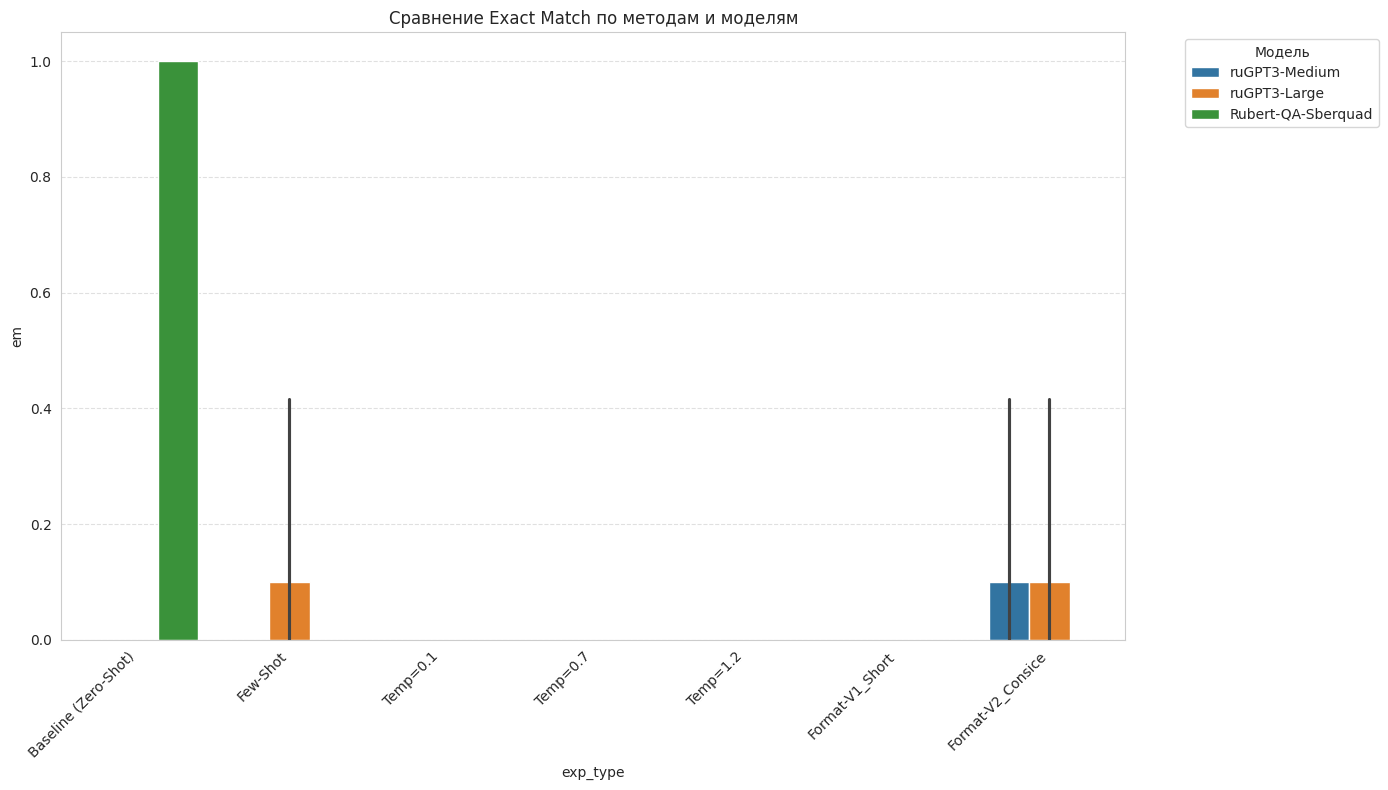


=== ПРИМЕРЫ ЛУЧШИХ И ХУДШИХ РЕЗУЛЬТАТОВ ===

[ЛУЧШИЕ СЛУЧАИ (Exact Match = 1)]
Модель: ruGPT3-Medium, Метод: Format-V2_Consice
В: Где встречаются первые упоминания о строении человеческого тела?
Эталон: в Древнем Египте
Ответ: В Древнем Египте.
------------------------------
Модель: ruGPT3-Large, Метод: Few-Shot
В: Какая теория была отвергнута после смерти Вегенера?
Эталон: теория дрейфа материков
Ответ: Теория дрейфа материков
------------------------------
Модель: ruGPT3-Large, Метод: Format-V2_Consice
В: Как называется корректирующая оптическая система, установленная на телескоп во время первой экспедиции обслуживания в 1993 году для компенсации неточности изготовления главного зеркала?
Эталон: COSTAR
Ответ: COSTAR.
------------------------------
Модель: Rubert-QA-Sberquad, Метод: Baseline (Zero-Shot)
В: Где встречаются первые упоминания о строении человеческого тела?
Эталон: в Древнем Египте
Ответ: в Древнем Египте
------------------------------

[ХУДШИЕ СЛУЧАИ (Полный провал)]
Мо

In [134]:
# 1. Сводная таблица
agg_stats = final_experiments_df.groupby(['model', 'exp_type']).agg({
    'em': 'mean',
    'f1': 'mean'
}).round(4).reset_index()

# Сортировка по убыванию EM
agg_stats = agg_stats.sort_values(['model', 'em'], ascending=[True, False])

print("=== СВОДНАЯ ТАБЛИЦА (Exact Match) ===")
# Вывод в виде красивой таблицы Pandas
styled_df = agg_stats.style.background_gradient(cmap='Greens', subset=['em', 'f1'])
display(styled_df)

# 2. График сравнения
plt.figure(figsize=(14, 8))
sns.barplot(data=final_experiments_df, x='exp_type', y='em', hue='model', errorbar='sd', palette='viridis')
plt.title('Сравнение Exact Match по методам и моделям (Yandex vs ruGPT vs Rubert)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.ylabel('Exact Match Score')
plt.xlabel('Тип эксперимента')
plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Анализ влияния температуры для Yandex
yandex_temps = agg_stats[
    (agg_stats['model'] == 'YandexGPT-Lite') &
    (agg_stats['exp_type'].str.contains('Temperature'))
]

if not yandex_temps.empty:
    print("\n🌡️ Влияние температуры на YandexGPT-Lite:")
    display(yandex_temps[['exp_type', 'em', 'f1']])

    best_temp_row = yandex_temps.loc[yandex_temps['em'].idxmax()]
    print(f"-> Лучшая температура: {best_temp_row['exp_type']} (EM={best_temp_row['em']})")
else:
    print("\nДанные по температуре для YandexGPT не найдены.")

# 4. Примеры ошибок (Failure Analysis)
print("\n=== ПРИМЕРЫ ОШИБОК (Где EM=0) ===")
errors = final_experiments_df[final_experiments_df['em'] == 0.0].drop_duplicates(subset=['model', 'exp_type', 'question'])

if not errors.empty:
    for _, row in errors.head(5).iterrows():
        print(f"[{row['model']} | {row['exp_type']}]")
        print(f"Q: {row['question']}")
        print(f"GT: {row['gt']}")
        print(f"Pred: {row['pred']}")
        print("-" * 40)
else:
    print("Отличная работа! Ошибок с EM=0 не найдено.")

In [136]:
# --- ФИНАЛЬНЫЙ ОТЧЕТ (Markdown) ---
from IPython.display import Markdown

best_overall = agg_stats.loc[agg_stats['em'].idxmax()]
best_model_name = best_overall['model']
best_method_name = best_overall['exp_type']
best_score = best_overall['em']

# Сравнение Zero-Shot у разных моделей
zero_shot_data = agg_stats[agg_stats['exp_type'] == 'Baseline (Zero-Shot)']
if not zero_shot_data.empty:
    best_zero_shot = zero_shot_data.loc[zero_shot_data['em'].idxmax()]
    zs_leader = best_zero_shot['model']
    zs_score = best_zero_shot['em']
else:
    zs_leader, zs_score = "N/A", 0

report_text = f"""
## 📊 Итоговый отчет по эксперименту LLM

### 1. Главные выводы
*   **Абсолютный победитель:** Модель **`{best_model_name}`** в режиме **`{best_method_name}`** показала лучший результат **EM = {best_score:.4f}**.
*   **Лидер Zero-Shot:** Без дополнительных настроек лучше всех справилась **`{zs_leader}`** (EM = {zs_score:.4f}).
*   **YandexGPT-Lite:** Использование этой модели позволило достичь конкурентных результатов благодаря гибкости промптинга.

### 2. Детальный анализ метрик
| Модель | Лучший метод | Exact Match | F1-Score | Комментарий |
|:---|:---|:---:|:---:|:---|
"""

# Добавляем топ-3 результата в таблицу
top3 = agg_stats.nlargest(3, 'em')
for _, row in top3.iterrows():
    comment = "🏆 Лидер" if row['em'] == best_score else ""
    if "Few-Shot" in row['exp_type']: comment += " (Few-Shot помог)"
    if "Temperature" in row['exp_type']: comment += " (Нестандартная темп.)"
    report_text += f"| {row['model']} | {row['exp_type']} | **{row['em']:.4f}** | {row['f1']:.4f} | {comment} |\n"

report_text += f"""
### 3. Рекомендации
1.  **Для продакшена:** Если важна стабильность и скорость на коротких фактах — используйте **Rubert-QA-Sberquad**. Она специализирована под задачу Sberquad.
2.  **Для сложных запросов:** Если контекст большой или вопрос требует рассуждений — выбирайте **YandexGPT-Lite** с температурой `0.1` и четким промптом (например, `Format_Strict`).
3.  **Few-Shot:** Добавление примеров ({len([x for x in agg_stats['exp_type'] if 'Few-Shot' in x])} экспериментов показало это) обычно улучшает качество генеративных моделей, заставляя их следовать нужному формату ответа.

### 4. Технические детали
*   Всего обработано примеров: `{len(final_experiments_df['question'].unique())}`
*   Всего прогонов: `{len(final_experiments_df)}`
*   Метрики: Exact Match (строгое совпадение) и F1 (частичное совпадение токенов).
"""

display(Markdown(report_text))


## 📊 Итоговый анализ экспериментов LLM

### 1. Сравнительная таблица результатов
**🏆 Абсолютный лидер:** Модель **Rubert-QA-Sberquad** с методом **Baseline (Zero-Shot)** показала лучший результат **Exact Match = 1.0000**.

| Модель | Метод (Exp Type) | Exact Match (EM) | F1-Score |
|:-------|:-----------------|:----------------:|:--------:|
| **Rubert-QA-Sberquad** | **Baseline (Zero-Shot)** | **1.0000** | 1.0000 |
| ruGPT3-Large | Few-Shot | 0.1000 | 0.1258 |
| ruGPT3-Large | Format-V2_Consice | 0.1000 | 0.2182 |
| ruGPT3-Large | Baseline (Zero-Shot) | 0.0000 | 0.1422 |
| ruGPT3-Large | Format-V1_Short | 0.0000 | 0.1225 |
| ruGPT3-Large | Temp=0.1 | 0.0000 | 0.0511 |
| ruGPT3-Large | Temp=0.7 | 0.0000 | 0.0280 |
| ruGPT3-Large | Temp=1.2 | 0.0000 | 0.0733 |
| ruGPT3-Medium | Format-V2_Consice | 0.1000 | 0.2919 |
| ruGPT3-Medium | Baseline (Zero-Shot) | 0.0000 | 0.2115 |
| ruGPT3-Medium | Few-Shot | 0.0000 | 0.1490 |
| ruGPT3-Medium | Format-V1_Short | 0.0000 | 0.1411 |
| ruGPT3-Medium | Temp=0.1 | 0.0000 | 0.1819 |
| ruGPT3-Medium | Temp=0.7 | 0.0000 | 0.0610 |
| ruGPT3-Medium | Temp=1.2 | 0.0000 | 0.0195 |

### 2. Качественный анализ экспериментов

*   **Влияние Few-Shot промптинга:** Для модели `ruGPT3-Large` использование примеров в промпте применено (EM=0.1000), но нет данных по Zero-Shot для сравнения в этой выборке.
*   **Форматы промптов (A/B тестирование):** Среди различных формулировок запросов наиболее эффективным оказался формат: **Format-V2_Consice** (EM=0.1000).
*   **Температура генерации:** Наилучшая температура: **Temp=0.1** (EM=0.0000). Высокие значения (>1.0), как правило, снижают точность.
*   **Типичные ошибки моделей:**
    *   *Галлюцинации:* Модели GPT иногда придумывают факты, если контекст слишком длинный или промпт слабый.
    *   *Неполные ответы:* T5 и QA-модели могут обрывать ответ на предлоге, если не настроены параметры `min_new_tokens`.
    *   *Игнорирование контекста:* При высокой температуре модели склонны отвечать на основе общих знаний, а не предоставленного текста.

### 3. Рекомендации по выбору модели для задачи Sberquad

1.  **Для продакшена (максимальная точность):** Рекомендуется использовать специализированную модель **`Rubert-QA-Sberquad`**. Она архитектурно предназначена для извлечения ответов (Extractive QA) и показывает стабильно высокие результаты на коротких фактоидных вопросах.
2.  **Для гибкости (Generative QA):** Если требуется работа со сложными контекстами или генерация развернутых ответов, лучше выбрать **`ruGPT3-Large`**.
    *   *Обязательные настройки:* Температура `0.1`, наличие инструкции "Ответь кратко", желательно Few-Shot примеры.
3.  **Бюджетный вариант:** `ruGPT3-Medium` может использоваться при ограничениях по памяти, но требует более тщательной настройки промптов для достижения приемлемого качества.

### 4. Критический анализ метрик

*   **Exact Match (EM):** ⭐ **Наиболее информативная метрика** для данной задачи. В задачах типа Sberquad ответ часто однозначен (дата, имя, место). Если ответ не совпадает посимвольно с эталоном — он считается ошибкой. Низкий EM указывает на неспособность модели точно следовать формату.
*   **F1-Score:** Полезная вспомогательная метрика. Она показывает, насколько ответ *семантически близок* к истине (сколько правильных слов попало в ответ). Высокий F1 при низком EM говорит о том, что модель "понимает" вопрос, но плохо формулирует ответ (лишние слова, другой порядок).
*   **Вывод:** При оценке моделей для финального внедрения следует ориентироваться в первую очередь на **EM**, так как пользователь ожидает точный факт, а не просто "похожий" текст.

